In [5]:
import os
import numpy as np
from astropy.wcs import WCS
from astropy import wcs
from astropy.table import Table
import requests
import matplotlib as mpl
import matplotlib.pyplot as plt
from astropy.modeling.functional_models import Ellipse2D
import matplotlib.patches as mpatches
from astropy.coordinates import SkyCoord
import astropy.units as u
import marvin
from marvin.tools.image import Image

import sys
sys.path.insert(1, '/Users/nityaravi/Documents/GitHub/RotationCurves/')

from GenerateCutout import get_cutout

In [6]:
mpl.rcParams['figure.dpi'] = 100
mpl.rcParams['savefig.dpi'] = 300
mpl.rcParams['figure.titlesize'] = 20
mpl.rcParams['axes.labelsize'] = 20
mpl.rcParams['xtick.labelsize'] = 15

In [7]:
cache_dir = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/legacy_survey/'
drp = Table.read('/Users/nityaravi/Documents/Research/RotationCurves/data/manga/output_files/DR17/CURRENT_MASTER_TABLE/Elliptical_sphdisk_refitspirals_BPT_v6.fits', format='fits', hdu=1)
test_gal = drp[2]

In [29]:
np.where(drp['plateifu'] == '11004-6104')

(array([1283]),)

In [22]:
test_gal = drp[293]

In [10]:
nsa = Table.read('/Users/nityaravi/Documents/Research/RotationCurves/data/nsa_v1_0_1.fits', format='fits')
nsa['ELPETRO_TH90_R

IAUNAME,SUBDIR,RA,DEC,ISDSS,INED,ISIXDF,IALFALFA,IZCAT,ITWODF,MAG,Z,ZSRC,SIZE,RUN,CAMCOL,FIELD,RERUN,XPOS,YPOS,NSAID,ZDIST,SERSIC_NMGY,SERSIC_NMGY_IVAR,SERSIC_OK,SERSIC_RNMGY,SERSIC_ABSMAG,SERSIC_AMIVAR,EXTINCTION,SERSIC_KCORRECT,SERSIC_KCOEFF,SERSIC_MTOL,SERSIC_B300,SERSIC_B1000,SERSIC_METS,SERSIC_MASS,XCEN,YCEN,NPROF,PROFMEAN,PROFMEAN_IVAR,QSTOKES,USTOKES,BASTOKES,PHISTOKES,PETRO_FLUX,PETRO_FLUX_IVAR,FIBER_FLUX,FIBER_FLUX_IVAR,PETRO_BA50,PETRO_PHI50,PETRO_BA90,PETRO_PHI90,SERSIC_FLUX,SERSIC_FLUX_IVAR,SERSIC_N,SERSIC_BA,SERSIC_PHI,ASYMMETRY,CLUMPY,DFLAGS,AID,PID,DVERSION,PROFTHETA,PETRO_THETA,PETRO_TH50,PETRO_TH90,SERSIC_TH50,PLATE,FIBERID,MJD,RACAT,DECCAT,ZSDSSLINE,SURVEY,PROGRAMNAME,PLATEQUALITY,TILE,PLUG_RA,PLUG_DEC,ELPETRO_BA,ELPETRO_PHI,ELPETRO_FLUX_R,ELPETRO_FLUX_IVAR_R,ELPETRO_THETA_R,ELPETRO_TH50_R,ELPETRO_TH90_R,ELPETRO_THETA,ELPETRO_FLUX,ELPETRO_FLUX_IVAR,ELPETRO_TH50,ELPETRO_TH90,ELPETRO_APCORR_R,ELPETRO_APCORR,ELPETRO_APCORR_SELF,ELPETRO_NMGY,ELPETRO_NMGY_IVAR,ELPETRO_OK,ELPETRO_RNMGY,ELPETRO_ABSMAG,ELPETRO_AMIVAR,ELPETRO_KCORRECT,ELPETRO_KCOEFF,ELPETRO_MASS,ELPETRO_MTOL,ELPETRO_B300,ELPETRO_B1000,ELPETRO_METS,IN_DR7_LSS
bytes19,bytes27,float64,float64,int32,int32,int32,int32,int32,int32,float32,float32,bytes7,float32,int16,uint8,int16,bytes3,float32,float32,int32,float32,float32[7],float32[7],int16,float32[7],float32[7],float32[7],float32[7],float32[7],float32[5],float32[7],float32,float32,float32,float32,float64,float64,uint8[7],"float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]",float32[7],float32[7],float32[7],float32[7],float32,float32,float32,float32,float32[7],float32[7],float32,float32,float32,float32[7],float32[7],int32[7],int32,int32,bytes8,float32[15],float32,float32,float32,float32,int32,int16,int32,float64,float64,float32,bytes6,bytes27,bytes8,int32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32[7],float32[7],float32[7],float32[7],float32,float32[7],float32[7],float32[7],float32[7],int16,float32[7],float32[7],float32[7],float32[7],float32[5],float32,float32[7],float32,float32,float32,float64
J094651.40-010228.5,09h/m00/J094651.40-010228.5,146.714215072841,-1.0412800233313741,0,72212,37354,-1,-1,-1,15.178774,0.021222278,sdss,0.07,756,1,206,301,136.2967,1095.152,0,0.020687785,29.696056 .. 3267.6895,0.29814342 .. 0.00012172792,1,31.368013 .. 3501.2527,-15.17281 .. -20.302134,223.03555 .. 1102.6129,0.4536473 .. 0.080934174,-0.005893635 .. 0.019576037,0.00017777947 .. 5.1533486e-11,0.00020792194 .. 0.98780394,2.7473723e-05,0.31195974,0.035135116,8898397000.0,215.39407348632812,213.4535369873047,10 .. 12,0.3149959 .. 0.0,233.37904 .. 0.0,0.062215745 .. -0.07950058,0.0006146176 .. -0.1274703,0.8828513 .. 0.7387829,0.2829979 .. -60.97547,18.203371 .. 2264.6604,1.9946122 .. 0.015697604,1.0260131 .. 561.97687,47.3397 .. 0.33574256,0.88909996,14.777527,0.80408496,17.367554,19.554192 .. 3146.785,1.0691423 .. 0.017162137,4.7761517,0.6651653,15.97821,-0.0109440535 .. 0.004525926,0.042470127 .. 0.042621203,0 .. 0,0,36,v2_1_13,0.22341923 .. 258.39,7.2478933,3.4641922,10.453795,5.882104,266,1,51630,146.71420341874853,-1.0412749124036818,0.0,sdss,legacy,good,122,146.71421,-1.0413043,0.80408496,17.367554,1144.0713,0.4582725,7.3913364,3.7061903,10.666219,7.3913364,18.787916 .. 2225.009,1.8480047 .. 0.017611798,5.8557696 .. 3.4004514,11.650886 .. 10.1460905,0.9986329,1.0687045 .. 1.001099,1.0695114 .. 1.0010818,28.532349 .. 2310.4973,0.42499655 .. 0.00024172392,1,28.661283 .. 2337.7668,-15.124495 .. -19.915525,293.50247 .. 1094.6666,-0.010805 .. 0.009306902,3.9630737e-05 .. 2.6251464e-06,6833158000.0,0.00017553588 .. 1.14686,0.004447123,0.09061434,0.025269886,0.0
J094630.85-004554.5,09h/m00/J094630.85-004554.5,146.6285851269414,-0.7651620976591762,1,-1,-1,-1,-1,-1,17.318521,0.06465632,sdss,0.06491773,1239,2,175,301,735.56384,1277.3636,1,0.06403577,2.4606192 .. 443.66675,5.447516 .. 0.006137319,1,2.6590455 .. 454.05856,-14.978118 .. -20.68

In [23]:
fn, w = get_cutout(test_gal['plateifu'], test_gal['objra'], test_gal['objdec'], 
                   test_gal['nsa_elpetro_th90'], cache_dir=cache_dir, verbose=1, layers=['default', 'model', 'resid'])

Get https://www.legacysurvey.org/viewer/cutout.jpg?ra=125.967743522&dec=21.4186635506&zoom=14&size=375&layer=ls-dr9
Get https://www.legacysurvey.org/viewer/cutout.jpg?ra=125.967743522&dec=21.4186635506&zoom=14&size=375&layer=ls-dr9-model
Get https://www.legacysurvey.org/viewer/cutout.jpg?ra=125.967743522&dec=21.4186635506&zoom=14&size=375&layer=ls-dr9-resid


In [19]:
center_ra = test_gal['objra']   # degrees
center_dec = test_gal['objdec'] # degrees

centers = SkyCoord(center_ra*u.deg, center_dec*u.deg)

# phi = SGA_disks['PA']*u.deg
phi = test_gal['nsa_elpetro_phi']*u.deg
#r26 = 0.5*SGA_disks['DIAM']*u.arcmin
r90 = test_gal['nsa_elpetro_th90']*u.arcsec

x = 1 # Determined during SV

# Maximum distance along the semi-major axis from the center coordinate for our endpoints
delta_a = x*r90
delta_b = delta_a * test_gal['nsa_elpetro_ba']

# Target positions
major_1 = centers.directional_offset_by(phi, x*delta_a)
major_2 = centers.directional_offset_by(phi + 180*u.deg, x*delta_a)
minor_1 = centers.directional_offset_by(phi-90*u.deg, x *delta_b)
minor_2 = centers.directional_offset_by(phi +90*u.deg, x *delta_b)

major_ra = [major_1.ra.value, major_2.ra.value]
major_dec = [major_1.dec.value, major_2.dec.value]

minor_ra = [minor_1.ra.value, minor_2.ra.value]
minor_dec = [minor_1.dec.value, minor_2.dec.value]

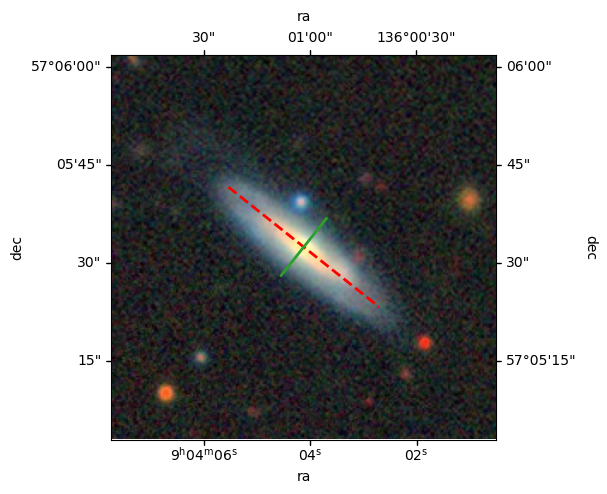

In [16]:
img = mpl.image.imread(fn)
fig = plt.figure(figsize=(5,5))

ax = fig.add_subplot(111, projection=w)
ax.imshow(np.flip(img, axis=0))
overlay = ax.get_coords_overlay('icrs')
ax.set(xlabel='ra', ylabel='dec')

ax.plot(major_ra, major_dec, transform=ax.get_transform('world'), color='r', linestyle='--', linewidth=2)
ax.plot(minor_ra, minor_dec, transform=ax.get_transform('world'), color='tab:green', linestyle='-', linewidth=2)


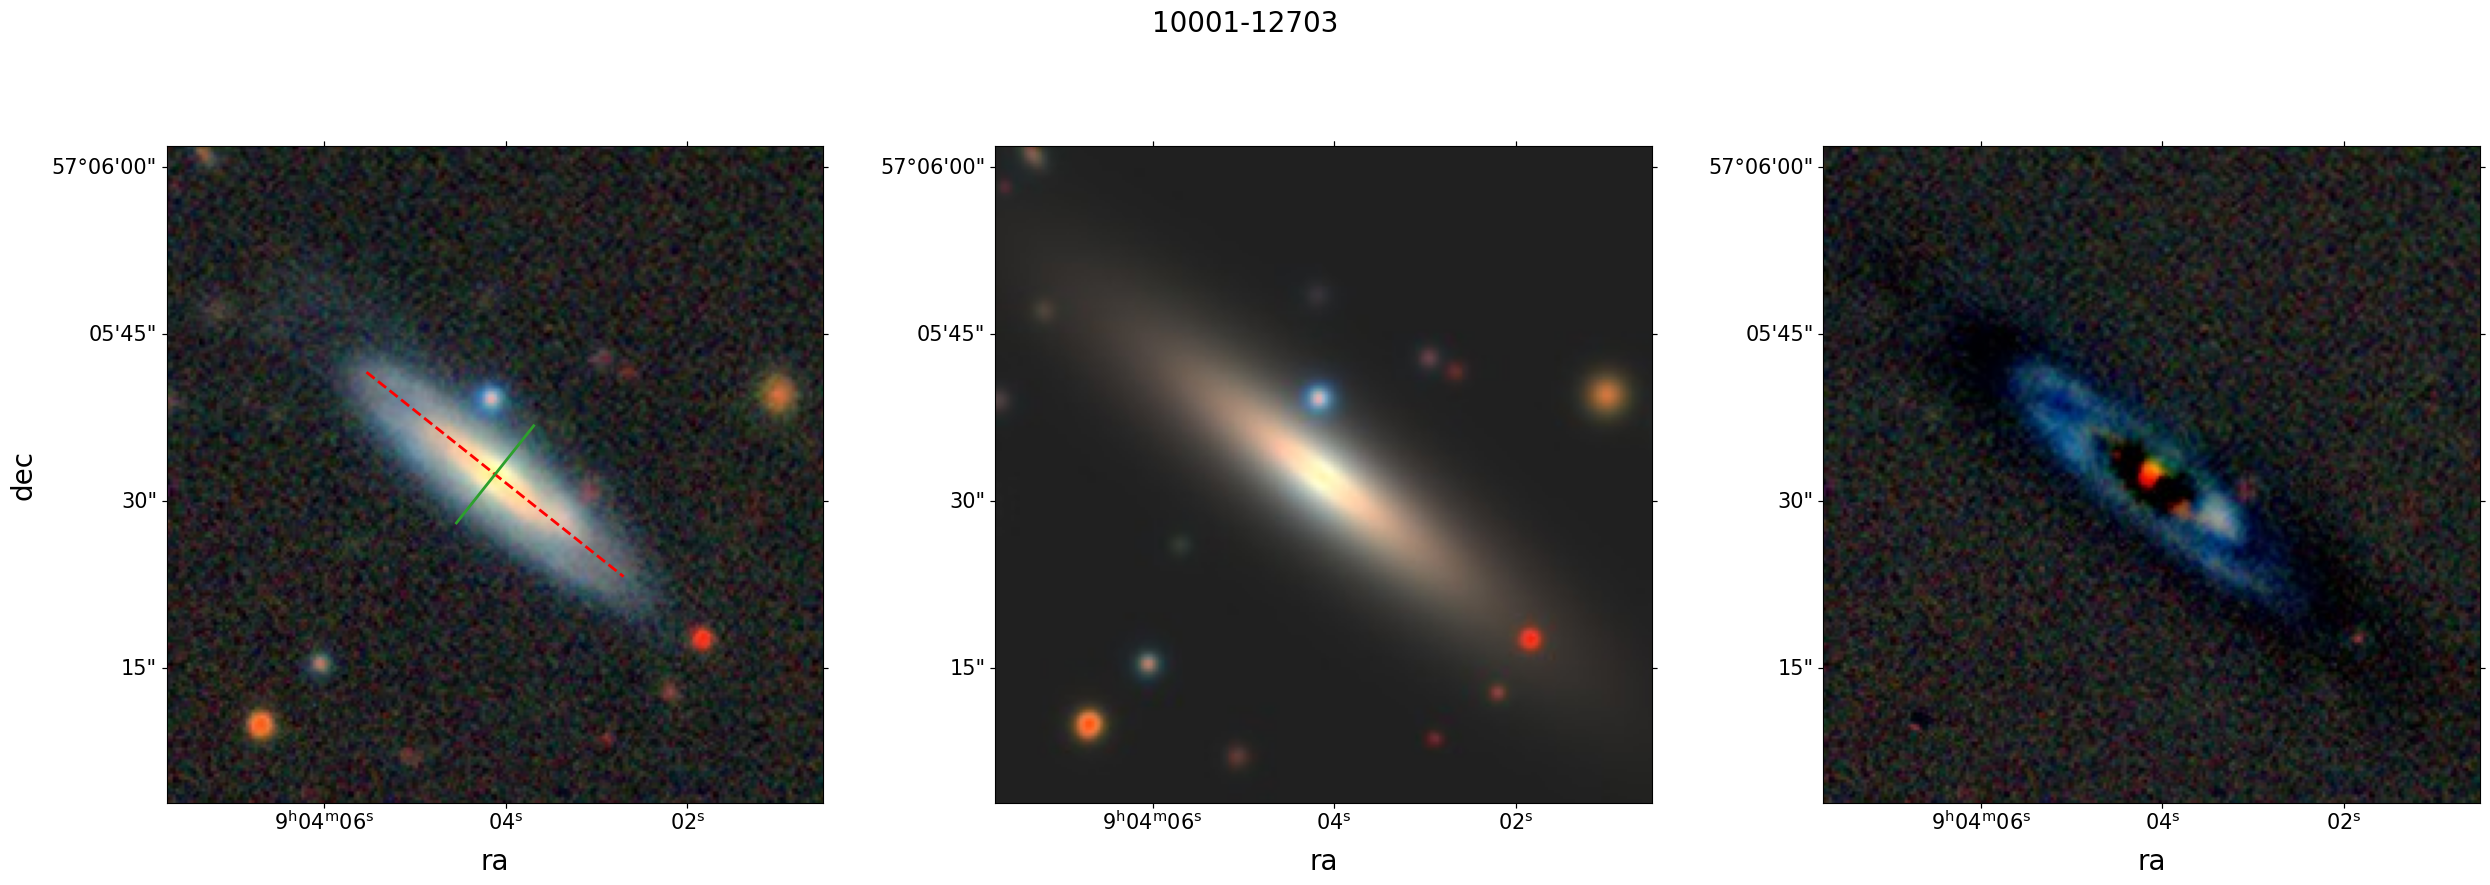

In [96]:
img = mpl.image.imread('/Users/nityaravi/Documents/Research/RotationCurves/data/manga/legacy_survey/default/10001-12703.jpg')
model = mpl.image.imread('/Users/nityaravi/Documents/Research/RotationCurves/data/manga/legacy_survey/model/10001-12703.jpg')
resid = mpl.image.imread('/Users/nityaravi/Documents/Research/RotationCurves/data/manga/legacy_survey/resid/10001-12703.jpg')


fig = plt.figure(figsize=(25,10))
ax1 = fig.add_subplot(1,3,1, projection=w)

ax1.imshow(np.flip(img, axis=0))
ax1.set(xlabel='ra', ylabel='dec')
ax1.plot(major_ra, major_dec, transform=ax1.get_transform('world'), color='r', linestyle='--', linewidth=2)
ax1.plot(minor_ra, minor_dec, transform=ax1.get_transform('world'), color='tab:green', linestyle='-', linewidth=2)


ax2 = fig.add_subplot(1,3,2, projection=w)
ax2.set(xlabel='ra', ylabel=' ')
ax2.imshow(np.flip(model, axis=0))

ax3 = fig.add_subplot(1,3,3, projection=w)
ax3.set(xlabel='ra', ylabel=' ')
ax3.imshow(np.flip(resid, axis=0))

fig.suptitle(test_gal['plateifu'])
fig.tight_layout()
fig.savefig(cache_dir + test_gal['plateifu'] + '.png', bbox_inches='tight')